In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [11]:

df = pd.read_csv(
    '../data/data.csv',
    encoding='utf-8-sig'
)

df.head()

,출발항코드(DEPARTURE_PORT_CODE),출발항명(DEPARTURE_PORT_NAME),도착항코드(DEST_PORT_CODE),도착항명(DEST_PORT_NAME),도착항국가(DEST_COUNTRY),기준일자(DATE),항만효율성(PORT_EFFICIENCY),총항해시간(TOTAL_SAILING_TIME),대기시간(WAITING_TIME),항만정시성(ON_TIME_PERFORMANCE)
0,KRPUS,부산항,AEJEA,제벨알리항,AE,2025-05-28,23.69,644.50,0.0,7.94
1,KRPUS,부산항,AEJEA,제벨알리항,AE,2025-06-11,22.01,608.54,0.0,16.20
2,KRPUS,부산항,AEJEA,제벨알리항,AE,2025-06-11,16.52,749.45,0.0,1.36
3,KRPUS,부산항,AEJEA,제벨알리항,AE,2025-06-30,22.37,634.28,0.0,7.44
4,KRPUS,부산항,AEJEA,제벨알리항,AE,2025-06-30,16.37,654.99,0.0,1.80


In [12]:
df.shape

(480, 10)

In [13]:
df.columns

Index(['출발항코드(DEPARTURE_PORT_CODE)', '출발항명(DEPARTURE_PORT_NAME)',
       '도착항코드(DEST_PORT_CODE)', '도착항명(DEST_PORT_NAME)', '도착항국가(DEST_COUNTRY)',
       '기준일자(DATE)', '항만효율성(PORT_EFFICIENCY)', '총항해시간(TOTAL_SAILING_TIME)',
       '대기시간(WAITING_TIME)', '항만정시성(ON_TIME_PERFORMANCE)'],
      dtype='str')

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   출발항코드(DEPARTURE_PORT_CODE)  480 non-null    str    
 1   출발항명(DEPARTURE_PORT_NAME)   480 non-null    str    
 2   도착항코드(DEST_PORT_CODE)       480 non-null    str    
 3   도착항명(DEST_PORT_NAME)        480 non-null    str    
 4   도착항국가(DEST_COUNTRY)         426 non-null    str    
 5   기준일자(DATE)                  480 non-null    str    
 6   항만효율성(PORT_EFFICIENCY)      480 non-null    float64
 7   총항해시간(TOTAL_SAILING_TIME)   480 non-null    float64
 8   대기시간(WAITING_TIME)          480 non-null    float64
 9   항만정시성(ON_TIME_PERFORMANCE)  480 non-null    float64
dtypes: float64(4), str(6)
memory usage: 59.8 KB


In [15]:
df.isna().sum()

출발항코드(DEPARTURE_PORT_CODE)     0
출발항명(DEPARTURE_PORT_NAME)      0
도착항코드(DEST_PORT_CODE)          0
도착항명(DEST_PORT_NAME)           0
도착항국가(DEST_COUNTRY)           54
기준일자(DATE)                     0
항만효율성(PORT_EFFICIENCY)         0
총항해시간(TOTAL_SAILING_TIME)      0
대기시간(WAITING_TIME)             0
항만정시성(ON_TIME_PERFORMANCE)     0
dtype: int64

In [16]:
df.describe()

,항만효율성(PORT_EFFICIENCY),총항해시간(TOTAL_SAILING_TIME),대기시간(WAITING_TIME),항만정시성(ON_TIME_PERFORMANCE)
count,480.000000,480.000000,480.000000,480.000000
mean,19.756458,432.292521,0.138042,6.431250
std,5.754084,415.966180,0.269674,25.602098
min,6.950000,28.970000,0.000000,-322.050000
25%,16.350000,75.985000,0.000000,1.940000
50%,18.735000,327.210000,0.030000,7.645000
75%,21.427500,624.942500,0.170000,13.950000
max,47.010000,1632.540000,3.040000,135.920000


In [17]:
#날짜 전처리
df['기준일자(DATE)'] = pd.to_datetime(
    df['기준일자(DATE)']
)

In [18]:

# 항만효율성
port_mean = df['항만효율성(PORT_EFFICIENCY)'].mean()
port_route_mean = df.groupby('도착항명(DEST_PORT_NAME)')['항만효율성(PORT_EFFICIENCY)'].mean()

# 대기시간
waiting_mean = df['대기시간(WAITING_TIME)'].mean()
waiting_route_mean = df.groupby('도착항명(DEST_PORT_NAME)')['대기시간(WAITING_TIME)'].mean()

# 정시성
on_time_mean = df['항만정시성(ON_TIME_PERFORMANCE)'].mean()
on_time_route_mean = df.groupby('도착항명(DEST_PORT_NAME)')['항만정시성(ON_TIME_PERFORMANCE)'].mean()

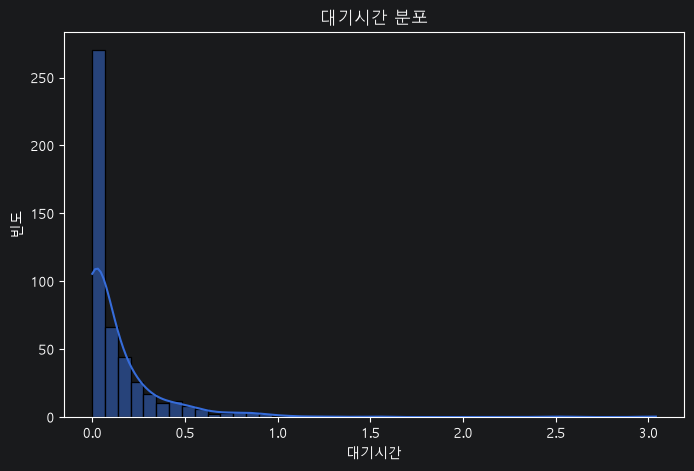

In [19]:
# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='대기시간(WAITING_TIME)',
    kde=True
)

plt.title('대기시간 분포')
plt.xlabel('대기시간')
plt.ylabel('빈도')

plt.show()

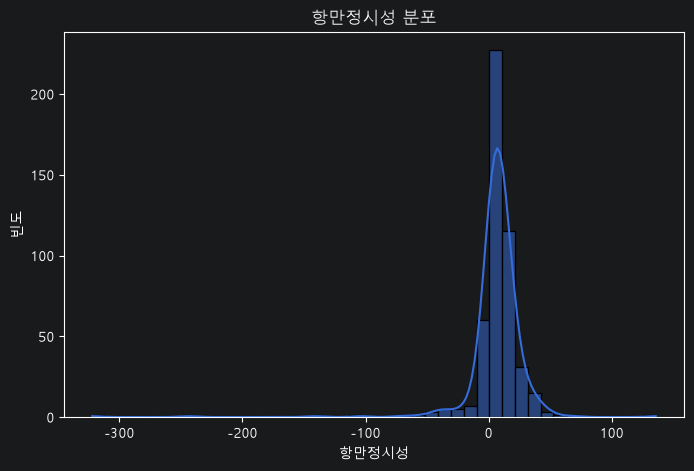

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='항만정시성(ON_TIME_PERFORMANCE)',
    kde=True
)

plt.title('항만정시성 분포')
plt.xlabel('항만정시성')
plt.ylabel('빈도')

plt.show()

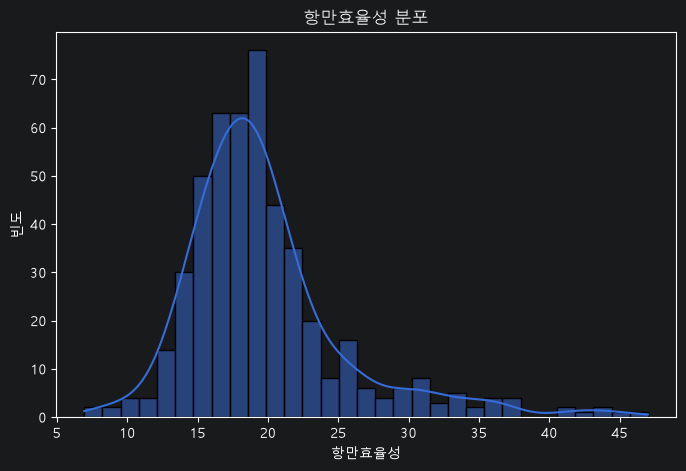

In [21]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='항만효율성(PORT_EFFICIENCY)',
    kde=True
)

plt.title('항만효율성 분포')
plt.xlabel('항만효율성')
plt.ylabel('빈도')

plt.show()

In [22]:
# 월별 평균
monthly = df.groupby(
    df['기준일자(DATE)'].dt.to_period('M')
).agg(
    대기시간=('대기시간(WAITING_TIME)', 'mean'),
    정시성=('항만정시성(ON_TIME_PERFORMANCE)', 'mean'),
    항만효율성=('항만효율성(PORT_EFFICIENCY)', 'mean')
)

monthly

,대기시간,정시성,항만효율성
기준일자(DATE),,,
2025-05,0.124000,2.961000,18.289000
2025-06,0.085909,12.595909,20.837273
2025-07,0.132222,0.971667,21.220000
2025-08,0.163077,4.223590,20.526923
2025-09,0.118966,7.213103,18.297931
2025-10,0.175745,7.485532,18.497447
2025-11,0.175000,1.828571,19.668571
2025-12,0.075455,13.738636,19.482273
2026-01,0.262647,8.828235,20.714412


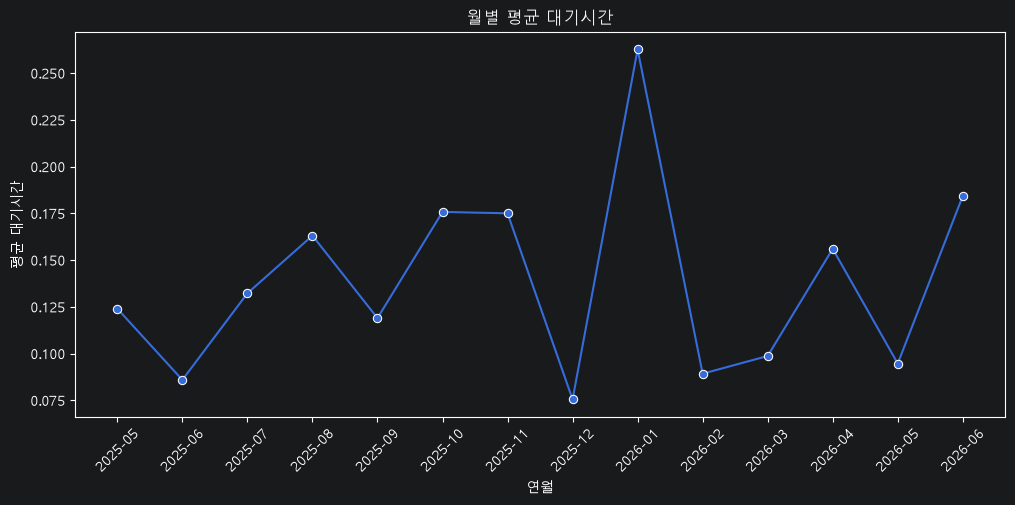

In [23]:
# 월별 대기시간

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly,
    x=monthly.index.astype(str),
    y='대기시간',
    marker='o'
)

plt.title('월별 평균 대기시간')
plt.xlabel('연월')
plt.ylabel('평균 대기시간')

plt.xticks(rotation=45)

plt.show()

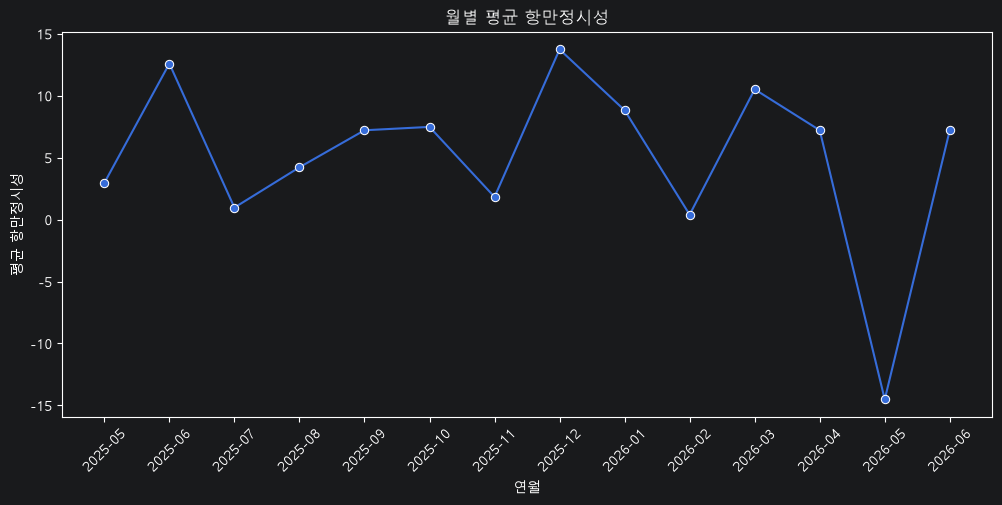

In [24]:
# 월별 정시성

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly,
    x=monthly.index.astype(str),
    y='정시성',
    marker='o'
)

plt.title('월별 평균 항만정시성')
plt.xlabel('연월')
plt.ylabel('평균 항만정시성')

plt.xticks(rotation=45)

plt.show()

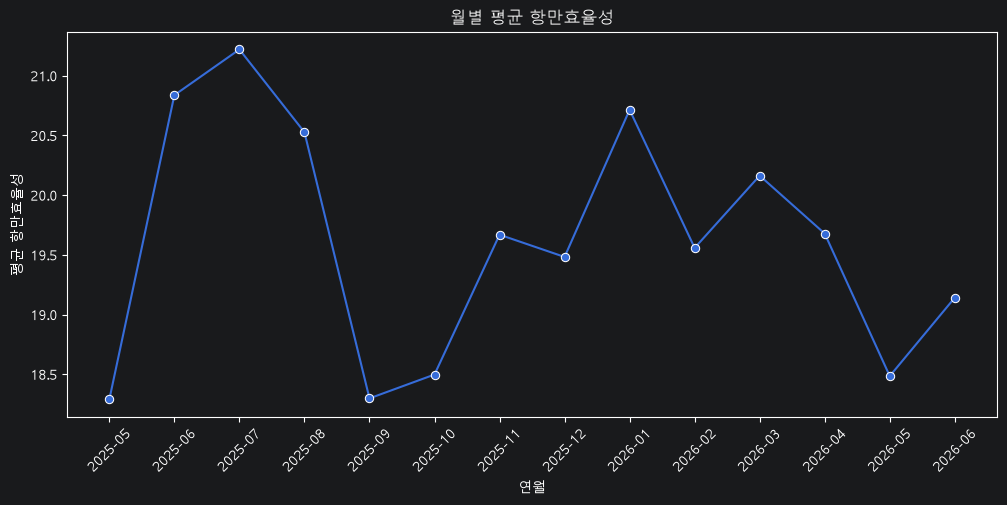

In [25]:
# 월별 항만효율성
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly,
    x=monthly.index.astype(str),
    y='항만효율성',
    marker='o'
)

plt.title('월별 평균 항만효율성')
plt.xlabel('연월')
plt.ylabel('평균 항만효율성')

plt.xticks(rotation=45)

plt.show()

In [26]:
# 노선별 평균

route = df.groupby('도착항명(DEST_PORT_NAME)').agg(
    대기시간=('대기시간(WAITING_TIME)', 'mean'),
    정시성=('항만정시성(ON_TIME_PERFORMANCE)', 'mean'),
    항만효율성=('항만효율성(PORT_EFFICIENCY)', 'mean')
)

route

,대기시간,정시성,항만효율성
도착항명(DEST_PORT_NAME),,,
KOBC PORT&LOGISTICS INDICATOR (종합),0.119074,8.529259,18.793148
뉴욕항,0.031143,17.179143,21.798286
램차방항,0.033333,1.833333,18.196667
로스앤젤레스항,0.011154,1.719808,18.337885
로테르담항,0.108000,9.443200,31.964800
상하이항,0.246346,11.616923,15.306731
싱가포르항,0.031296,14.412037,20.343704
안트베르펜항,0.135652,5.256087,27.923478
제벨알리항,0.000000,4.439189,19.531351


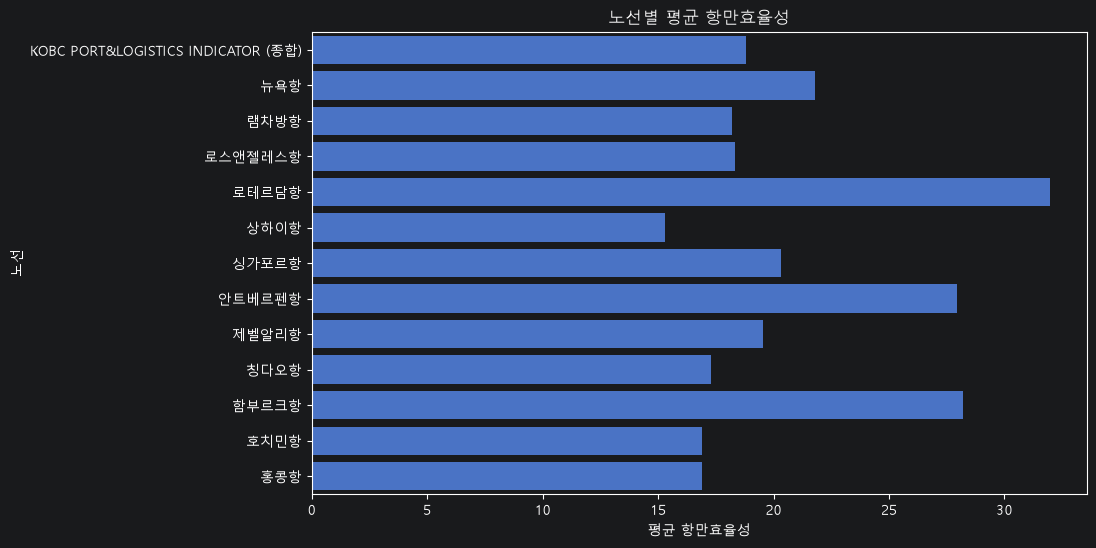

In [27]:
# 노선별 항만효율성

plt.figure(figsize=(10, 6))

sns.barplot(
    data=route.reset_index(),
    x='항만효율성',
    y='도착항명(DEST_PORT_NAME)'
)

plt.title('노선별 평균 항만효율성')
plt.xlabel('평균 항만효율성')
plt.ylabel('노선')

plt.show()

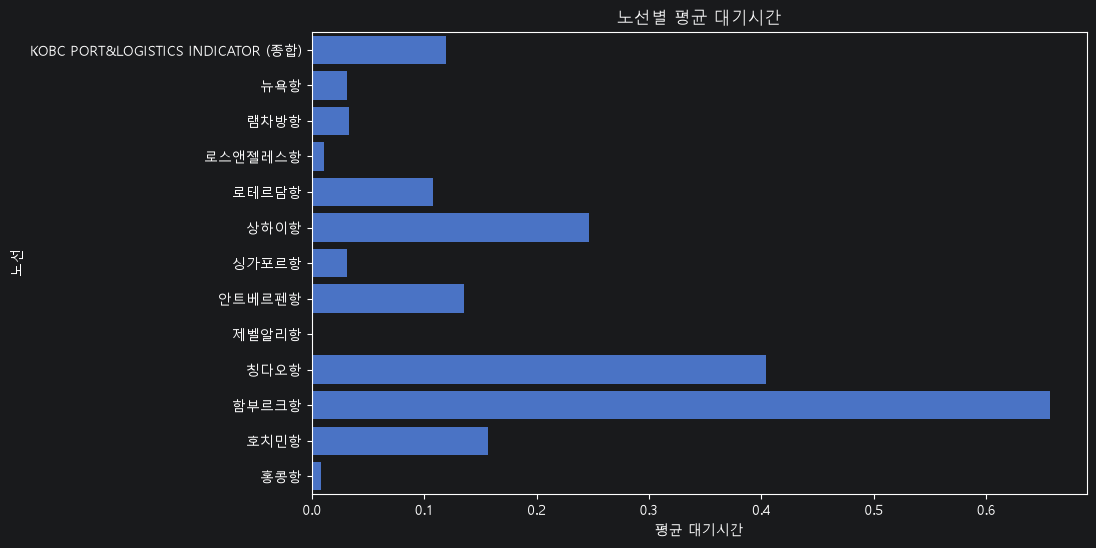

In [28]:
# 노선별 대기시간

plt.figure(figsize=(10, 6))

sns.barplot(
    data=route.reset_index(),
    x='대기시간',
    y='도착항명(DEST_PORT_NAME)'
)

plt.title('노선별 평균 대기시간')
plt.xlabel('평균 대기시간')
plt.ylabel('노선')

plt.show()

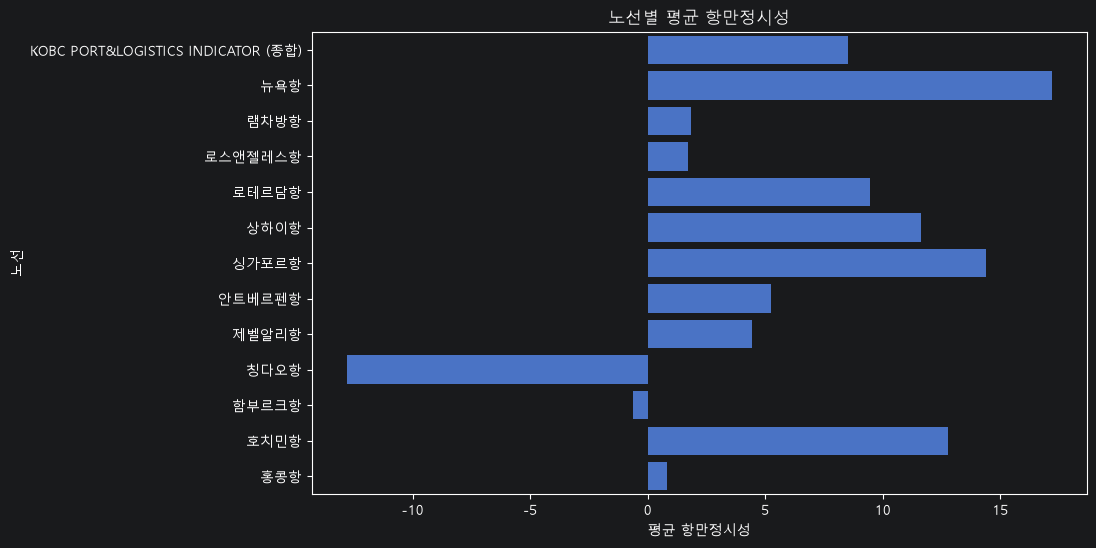

In [29]:
# 노선별 정시성

plt.figure(figsize=(10, 6))

sns.barplot(
    data=route.reset_index(),
    x='정시성',
    y='도착항명(DEST_PORT_NAME)'
)

plt.title('노선별 평균 항만정시성')
plt.xlabel('평균 항만정시성')
plt.ylabel('노선')

plt.show()

In [30]:
df[
    [
        '대기시간(WAITING_TIME)',
        '항만효율성(PORT_EFFICIENCY)'
    ]
].corr()

,대기시간(WAITING_TIME),항만효율성(PORT_EFFICIENCY)
대기시간(WAITING_TIME),1.000000,0.094965
항만효율성(PORT_EFFICIENCY),0.094965,1.000000


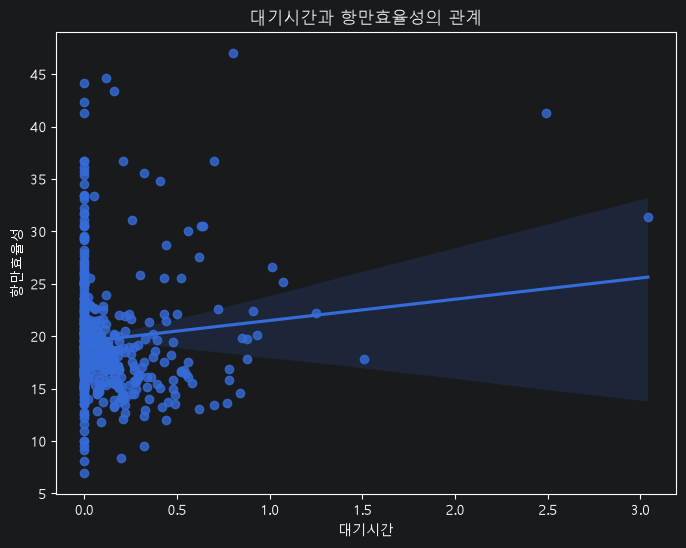

In [31]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x='대기시간(WAITING_TIME)',
    y='항만효율성(PORT_EFFICIENCY)'
)

plt.title('대기시간과 항만효율성의 관계')
plt.xlabel('대기시간')
plt.ylabel('항만효율성')

plt.show()

In [32]:
df[
    [
        '항만정시성(ON_TIME_PERFORMANCE)',
        '항만효율성(PORT_EFFICIENCY)'
    ]
].corr()

,항만정시성(ON_TIME_PERFORMANCE),항만효율성(PORT_EFFICIENCY)
항만정시성(ON_TIME_PERFORMANCE),1.000000,0.030256
항만효율성(PORT_EFFICIENCY),0.030256,1.000000


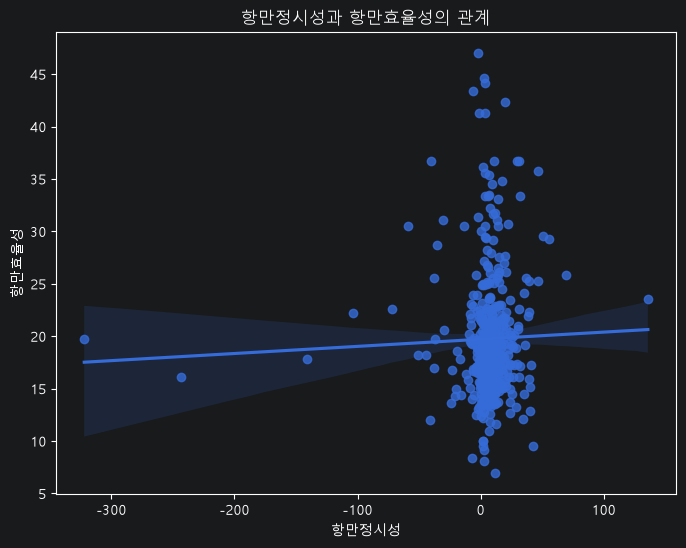

In [33]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x='항만정시성(ON_TIME_PERFORMANCE)',
    y='항만효율성(PORT_EFFICIENCY)'
)

plt.title('항만정시성과 항만효율성의 관계')
plt.xlabel('항만정시성')
plt.ylabel('항만효율성')

plt.show()

In [34]:
# 변수 세개 상관관계

corr = df[
    [
        '대기시간(WAITING_TIME)',
        '항만정시성(ON_TIME_PERFORMANCE)',
        '항만효율성(PORT_EFFICIENCY)'
    ]
].corr()

corr

,대기시간(WAITING_TIME),항만정시성(ON_TIME_PERFORMANCE),항만효율성(PORT_EFFICIENCY)
대기시간(WAITING_TIME),1.000000,-0.238045,0.094965
항만정시성(ON_TIME_PERFORMANCE),-0.238045,1.000000,0.030256
항만효율성(PORT_EFFICIENCY),0.094965,0.030256,1.000000


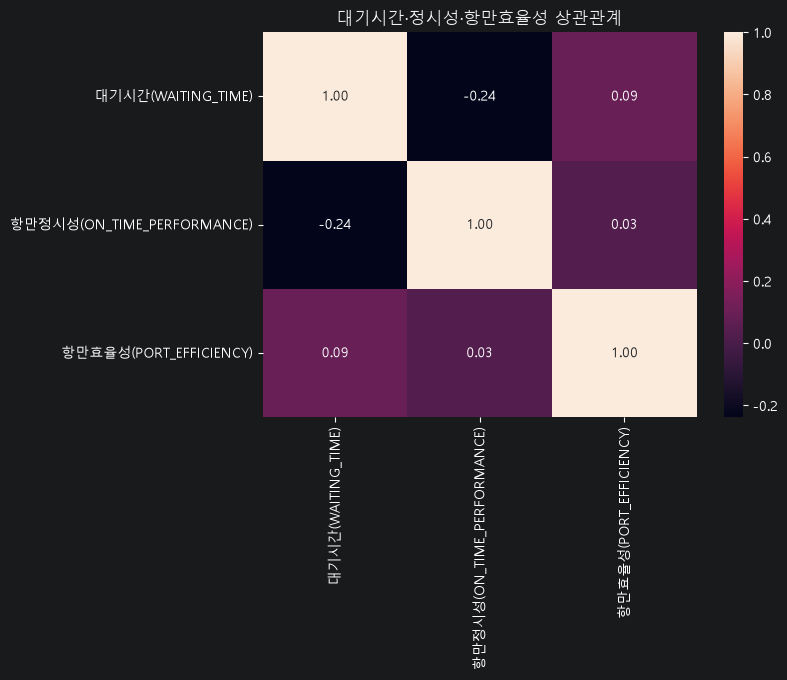

In [35]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f'
)

plt.title('대기시간·정시성·항만효율성 상관관계')

plt.show()